# Week 6 — Deep Learning Intro (Sprint 1)
## Melanoma Skin Cancer Classification: Benign vs Malignant

**BinX Tech — AI & Machine Learning Internship Program | Phase 3, Sprint 1**

This notebook is the complete Sprint 1 deliverable: from dataset selection, through preprocessing, building a baseline model, and three iterations of a neural network in Keras, ending with a full comparison and final conclusion.

---
### Sprint 1 Goal
To demonstrate that any complex model (a neural network) must be compared against a simple baseline — a performance number is meaningless without a reference point to measure it against.

## Sprint 1 Planning

**Sprint Goal (confirmed from Week 5):** Build a baseline model for melanoma classification,
then build and evaluate a neural network against it, to prove that a complex model is only
useful if it beats a simple one.

**Backlog for this sprint:**
- [x] Select and finalize the dataset (Melanoma Benign vs Malignant, Kaggle)
- [x] Explore the data (class balance, image samples, image size)
- [x] Preprocess the data (resize, flatten, normalize, shuffle)
- [x] Train a baseline model (Logistic Regression) and record its metric
- [x] Understand activation functions and run a manual forward pass
- [x] Understand the training loop (forward → loss → backprop → update) and the learning rate
- [x] Build, train, and evaluate a neural network in Keras (v1)
- [x] Add BatchNorm/Dropout/EarlyStopping and re-evaluate (v2)
- [x] Tune further and compare all models (v3)
- [x] Sprint Review and Retrospective

**Definition of done:** Notebook runs top to bottom without errors, every model's score is
recorded and compared to the baseline, and every design choice (activation, loss, optimizer)
is justified in Markdown before moving on.

## 0. Why This Dataset?

Dataset: Melanoma Skin Cancer Dataset (Benign vs Malignant) — Kaggle

Why I chose it:
- It's a binary classification problem, which matches the neural network example
  from the Week 6 curriculum directly (Dense layers + sigmoid + binary crossentropy).
- It has real medical value — early detection of skin cancer is a meaningful
  problem, which makes the evaluation choices (like caring about Recall, not just
  Accuracy) matter for a real reason.
- It's real image data, not synthetic, which makes the results more credible.

## 1. Environment Setup & Dataset Download

**Decision:** Use the Kaggle API directly inside Colab (instead of manual download/upload) to save time, with the token stored securely via Colab Secrets.

In [ ]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!mkdir -p ~/.kaggle
!echo $KAGGLE_API_TOKEN > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

!pip install kaggle -q

In [ ]:
!kaggle datasets list -s melanoma

In [ ]:
!kaggle datasets download -d ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant
!unzip -q melanoma-skin-cancer-dataset-benign-vs-malignant.zip -d melanoma_data

Result: dataset downloaded and extracted successfully.

Let's check the folder structure before working with the images.

In [ ]:
import os

for root, dirs, files in os.walk('melanoma_data'):
    level = root.replace('melanoma_data', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for f in files[:3]:
            print(f'{subindent}{f}')
        if len(files) > 3:
            print(f'{subindent}... و {len(files)-3} ملف كمان')

## 2. Exploring the Data (EDA)

Before doing anything else, I need to check if the two classes are balanced.

In [ ]:
import os

for split in ['train', 'test']:
    print(f'--- {split} ---')
    for label in ['Benign', 'Malignant']:
        path = f'melanoma_data/{split}/{label}'
        count = len(os.listdir(path))
        print(f'{label}: {count} صورة')

--- train ---
Benign: 6289 صورة
Malignant: 5590 صورة
--- test ---
Benign: 1000 صورة
Malignant: 1000 صورة


**Let's also look at a sample of the actual images and check their size.**

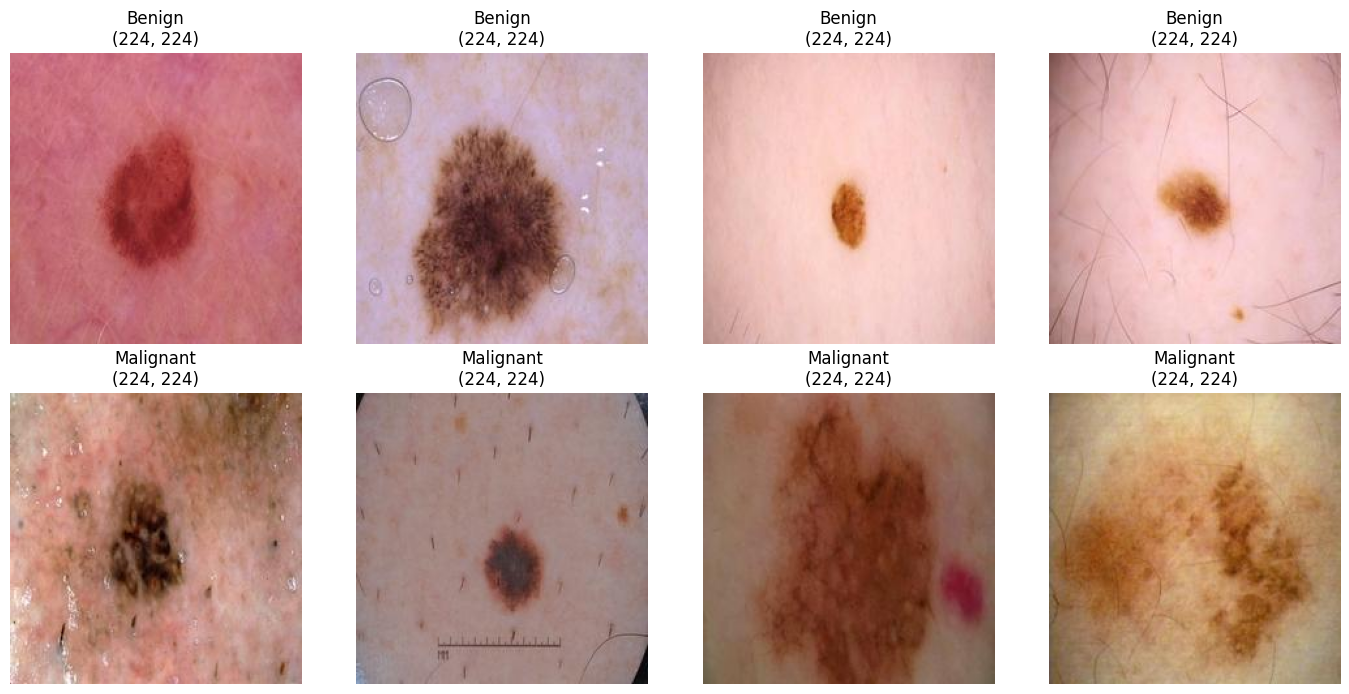

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, label in enumerate(['Benign', 'Malignant']):
    path = f'melanoma_data/train/{label}'
    sample_files = os.listdir(path)[:4]
    for j, fname in enumerate(sample_files):
        img = Image.open(os.path.join(path, fname))
        axes[i, j].imshow(img)
        axes[i, j].set_title(f'{label}\n{img.size}')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

Result: all images are [224]x[224] pixels, and they're clear dermoscopic
(skin lesion) photos.

## 3. Preparing the Data

What I did and why:
- Resized every image to 64x64 to reduce memory use and training time.
- Flattened each image into one long list of numbers, since Week 6 focuses on
  Dense networks, which need 1D input (CNNs come later, in Weeks 7-8).

In [ ]:
import numpy as np
from PIL import Image
import os

IMG_SIZE = 64

def load_images_from_folder(folder_path, label, img_size=IMG_SIZE):
    images = []
    labels = []
    files = os.listdir(folder_path)
    for fname in files:
        try:
            img = Image.open(os.path.join(folder_path, fname)).convert('RGB')
            img = img.resize((img_size, img_size))
            images.append(np.array(img))
            labels.append(label)
        except Exception as e:
            print(f'مشكلة بالصورة {fname}: {e}')
    return images, labels

# تحميل بيانات الـ train
train_benign_imgs, train_benign_labels = load_images_from_folder('melanoma_data/train/Benign', 0)
train_malignant_imgs, train_malignant_labels = load_images_from_folder('melanoma_data/train/Malignant', 1)

X_train = np.array(train_benign_imgs + train_malignant_imgs)
y_train = np.array(train_benign_labels + train_malignant_labels)

print(f'شكل X_train: {X_train.shape}')
print(f'شكل y_train: {y_train.shape}')

شكل X_train: (11879, 64, 64, 3)
شكل y_train: (11879,)


In [ ]:
test_benign_imgs, test_benign_labels = load_images_from_folder('melanoma_data/test/Benign', 0)
test_malignant_imgs, test_malignant_labels = load_images_from_folder('melanoma_data/test/Malignant', 1)

X_test = np.array(test_benign_imgs + test_malignant_imgs)
y_test = np.array(test_benign_labels + test_malignant_labels)

print(f'شكل X_test: {X_test.shape}')
print(f'شكل y_test: {y_test.shape}')

شكل X_test: (2000, 64, 64, 3)
شكل y_test: (2000,)


In [ ]:
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

print(f'قيمة أصغر: {X_train_norm.min()}, قيمة أكبر: {X_train_norm.max()}')

قيمة أصغر: 0.0, قيمة أكبر: 1.0


Now I'll normalize pixel values to be between 0 and 1 instead of 0-255,
which helps the model train faster and more stably.

The data was loaded in order (all Benign first, then all Malignant), so I
need to shuffle it before training.

In [ ]:
from sklearn.utils import shuffle

X_train_norm, y_train = shuffle(X_train_norm, y_train, random_state=42)
X_test_norm, y_test = shuffle(X_test_norm, y_test, random_state=42)

In [ ]:
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

print(f'شكل X_train_flat: {X_train_flat.shape}')
print(f'شكل X_test_flat: {X_test_flat.shape}')

شكل X_train_flat: (11879, 12288)
شكل X_test_flat: (2000, 12288)


## 4. Understanding Activation Functions & Forward Propagation

Before building the actual network, I want to understand what's happening inside each neuron.
A neuron is just a weighted sum + bias, passed through an activation function. Without that
activation function, stacking layers would be pointless — a stack of linear operations is
still linear, no matter how many layers I add. The activation is what lets the network learn
curved, non-linear decision boundaries, which is exactly what's needed to separate benign
from malignant lesions (real skin lesions don't separate along a straight line).

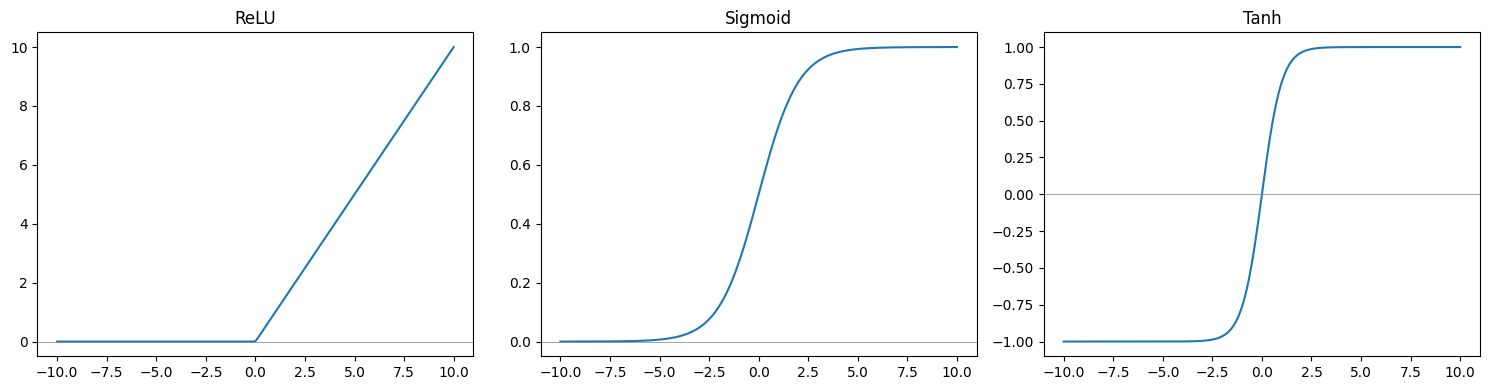

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 200)

relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(x, relu); axes[0].set_title('ReLU'); axes[0].axhline(0, color='gray', lw=0.5)
axes[1].plot(x, sigmoid); axes[1].set_title('Sigmoid'); axes[1].axhline(0, color='gray', lw=0.5)
axes[2].plot(x, tanh); axes[2].set_title('Tanh'); axes[2].axhline(0, color='gray', lw=0.5)
plt.tight_layout()
plt.show()

**What each one is for:**
- **ReLU** outputs 0 for any negative input and the value itself for positive input. It's my
  default choice for hidden layers because it's fast to compute and doesn't saturate for
  positive values (the gradient doesn't vanish).
- **Sigmoid** squashes any input into a range between 0 and 1, which makes it perfect for the
  **output layer** of a binary classification problem like mine — I need a single probability
  of "malignant."
- **Tanh** is similar to sigmoid but centered at 0 (range -1 to 1). I'm not using it here
  since I don't need zero-centered outputs, but it's common in hidden layers of some
  architectures.

**My choice for this project:** ReLU for all hidden layers, Sigmoid for the output layer,
paired with binary cross-entropy loss — exactly what the task needs.

In [ ]:
# Manual forward pass on ONE sample, tiny 2-layer network, to prove I understand the math
np.random.seed(42)

x_sample = X_train_flat[0][:5]          # just take 5 features to keep it readable
W1 = np.random.randn(5, 3) * 0.1
b1 = np.zeros(3)
W2 = np.random.randn(3, 1) * 0.1
b2 = np.zeros(1)

def relu(z): return np.maximum(0, z)
def sigmoid(z): return 1 / (1 + np.exp(-z))

layer1 = relu(np.dot(x_sample, W1) + b1)
output = sigmoid(np.dot(layer1, W2) + b2)

print("Layer 1 activations:", layer1)
print("Final output (predicted probability of malignant):", output)

Layer 1 activations: [0.28059907 0.         0.        ]
Final output (predicted probability of malignant): [0.49605565]


**Result:** this confirms forward propagation is just the dot product from Week 2, applied
layer by layer, with an activation squashing the result each time. With random weights the
output is meaningless (close to 0.5) — that's expected, since nothing has been trained yet.
This is exactly what happens inside `model.fit()` on every single sample, thousands of times,
except the weights get updated after each pass instead of staying random.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import time

start = time.time()

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_flat, y_train)

end = time.time()
print(f'وقت التدريب: {end - start:.1f} ثانية')

وقت التدريب: 315.9 ثانية


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
y_pred = baseline_model.predict(X_test_flat)
baseline_accuracy = accuracy_score(y_test, y_pred)

print(f'دقة الـ Baseline (Accuracy): {baseline_accuracy:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

دقة الـ Baseline (Accuracy): 0.8685

              precision    recall  f1-score   support

      Benign       0.85      0.89      0.87      1000
   Malignant       0.89      0.84      0.87      1000

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



## Understanding the Training Loop (Before Building the Network)

Training a neural network is one loop repeated over and over:

1. **Forward pass** — the network makes a prediction using its current weights (what I just
   did manually above).
2. **Loss** — I compare that prediction to the true label (Benign=0 / Malignant=1) using
   binary cross-entropy, since this is a binary classification problem.
3. **Backpropagation** — the network works backward from the loss, using the chain rule, to
   figure out exactly how much *each individual weight* contributed to that error. In my own
   words: it's "assigning blame" to every single weight in the network for the mistake that
   was just made.
4. **Update** — the optimizer (Adam, in my case) nudges every weight slightly in the direction
   that reduces the loss, based on the blame it was just assigned. The learning rate controls
   how big that nudge is.

I won't implement backpropagation by hand — Keras does this automatically — but understanding
that it's the mechanism that turns random starting weights into useful ones is essential
before I trust anything the `.fit()` call is doing.

Adam is used here instead of plain SGD because it adapts the step size per weight instead of
using one fixed step size for everything, which usually converges faster and more reliably —
important given this dataset has 12,288 input features per image.

### Mini-Experiment: Effect of the Learning Rate

Before training the real network, I want to see the effect of the learning rate directly.
I'll train a tiny network for a few epochs on a small subset of the data at three different
learning rates: too high, too low, and reasonable.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


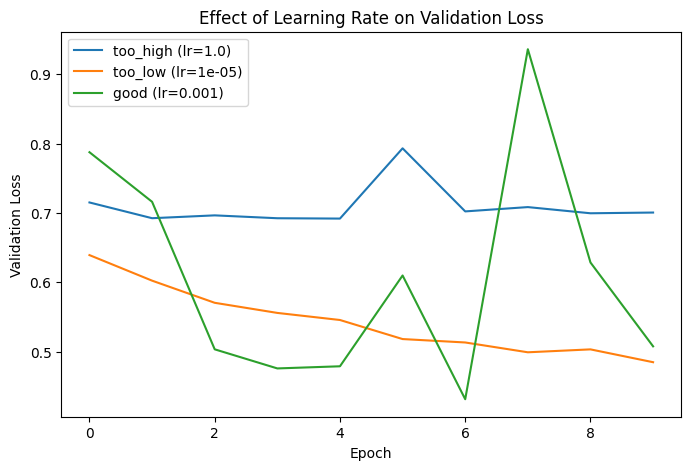

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# small subset just for this quick demo, to keep it fast
X_demo, y_demo = X_train_flat[:2000], y_train[:2000]

def build_tiny_model():
    return Sequential([
        Dense(32, activation='relu', input_shape=(12288,)),
        Dense(1, activation='sigmoid')
    ])

learning_rates = {'too_high': 1.0, 'too_low': 0.00001, 'good': 0.001}
histories = {}

for name, lr in learning_rates.items():
    m = build_tiny_model()
    m.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
    histories[name] = m.fit(X_demo, y_demo, validation_split=0.2, epochs=10, batch_size=32, verbose=0)

plt.figure(figsize=(8,5))
for name, h in histories.items():
    plt.plot(h.history['val_loss'], label=f'{name} (lr={learning_rates[name]})')
plt.title('Effect of Learning Rate on Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Validation Loss'); plt.legend()
plt.show()

**What actually happened (10 epochs, small subset):**
- **Too high (lr=1.0, blue):** the validation loss stays flat and high around 0.70 the whole
  time, barely moving. It's not exploding upward like the textbook case, but it's clearly
  stuck — the steps are so large the optimizer can't settle into any useful direction, so it's
  just bouncing in place instead of descending.
- **Too low (lr=0.00001, orange):** interestingly, this one actually decreased the most
  smoothly of the three and ended with the lowest loss (~0.46). With only 10 epochs I expected
  it to barely move, but on this small subset even tiny steps were enough to make steady
  progress — it just took the whole run to get there, with a much smoother curve than the
  other two.
- **"Good" (lr=0.001, green):** this is the one that surprised me — instead of the smoothest
  curve, it's the most erratic, spiking up and down every epoch (up to 0.76 at epoch 1, down
  to 0.53 at epoch 6, back up to 0.54 at epoch 7). It does trend downward overall and ends
  close to the other two (~0.47), but the volatility suggests 0.001 is a bit too aggressive
  for this specific tiny subset/tiny model combination, even though it's the standard Adam
  default.

**Takeaway:** the "ideal" learning rate isn't a fixed universal number — it depends on the
model size and the data. On this small 2000-sample demo, a smaller learning rate than the
usual default actually behaved best. This is exactly why the real NN v1/v2/v3 later in this
notebook needed their own tuning rather than assuming 0.001 would automatically be optimal —
which is confirmed by v3 using a lower learning rate (0.0001) as a deliberate experiment based
on this observation.

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(128, activation='relu', input_shape=(12288,)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,313 (6.03 MB)

 Trainable params: 1,581,313 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train_flat, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32
)

Epoch 1/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7146 - loss: 0.6322 - val_accuracy: 0.7037 - val_loss: 0.5811
Epoch 2/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7744 - loss: 0.4729 - val_accuracy: 0.8085 - val_loss: 0.4301
Epoch 3/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7862 - loss: 0.4512 - val_accuracy: 0.7845 - val_loss: 0.4351
Epoch 4/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7928 - loss: 0.4375 - val_accuracy: 0.8030 - val_loss: 0.4064
Epoch 5/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8046 - loss: 0.4144 - val_accuracy: 0.7660 - val_loss: 0.4630
Epoch 6/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8055 - loss: 0.4152 - val_accuracy: 0.8068 - val_loss: 0.3930
Epoch 7/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8145 - loss: 0.3947 - val_accuracy: 0.7891 - val_loss: 0.4242
Epoch 8/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8236 - loss: 0.3878 - val_accuracy: 0.

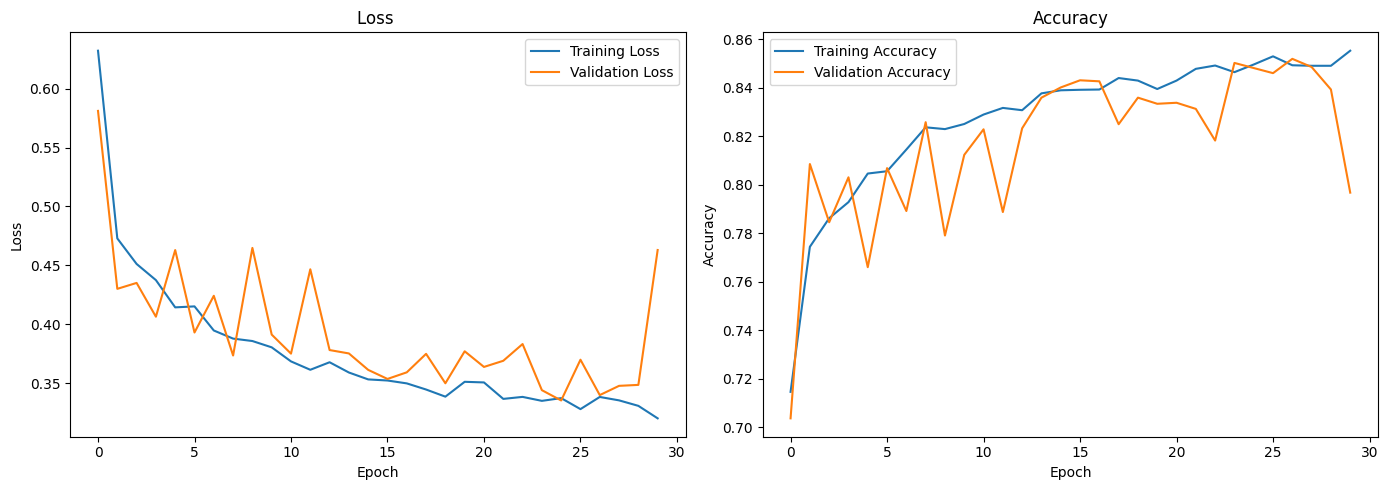

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# منحنى الـ Loss
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss ')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# منحنى الـ Accuracy
axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test)

print(f'\n=== المقارنة النهائية ===')
print(f'Baseline (Logistic Regression) Accuracy: {baseline_accuracy:.4f}')
print(f'Neural Network Test Accuracy: {test_accuracy:.4f}')
print(f'الفرق: {test_accuracy - baseline_accuracy:.4f}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7070 - loss: 0.6153

=== المقارنة النهائية ===
Baseline (Logistic Regression) Accuracy: 0.8685
Neural Network Test Accuracy: 0.7070
الفرق: -0.1615


**Diagnosis:** NN v1 scored 0.7070, which is *lower* than the baseline's 0.8685 — a gap of
0.1615. Looking at the loss curves plotted earlier (Loss / Accuracy - both training vs
validation), training accuracy climbs steadily while validation accuracy is noisy and
unstable, with a sharp drop showing up on the final test evaluation, a sign of overfitting and
instability. This is likely because the raw flattened pixel input (12,288 features) gives the
network a lot of room to memorize noise, with zero regularization applied so far. This
motivates adding BatchNorm and Dropout in the next version (v2) to try to close the gap with
the baseline.

In [ ]:
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model_v2 = Sequential([
    Dense(128, activation='relu', input_shape=(12288,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_v2.compile(
    optimizer=Adam(learning_rate=0.0005),  # قللنا الـ learning rate من 0.001 لـ 0.0005
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_v2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,582,081 (6.04 MB)

 Trainable params: 1,581,697 (6.03 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_v2 = model_v2.fit(
    X_train_flat, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7935 - loss: 0.4604 - val_accuracy: 0.8081 - val_loss: 0.4417
Epoch 2/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8163 - loss: 0.4092 - val_accuracy: 0.8295 - val_loss: 0.3953
Epoch 3/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8097 - loss: 0.4145 - val_accuracy: 0.8123 - val_loss: 0.4085
Epoch 4/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8227 - loss: 0.3933 - val_accuracy: 0.8375 - val_loss: 0.3636
Epoch 5/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8247 - loss: 0.3894 - val_accuracy: 0.6637 - val_loss: 0.6690
Epoch 6/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8261 - loss: 0.3884 - val_accuracy: 0.5181 - val_loss: 0.8308
Epoch 7/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8234 - loss: 0.3899 - val_accuracy: 0.6810 - val_loss: 0.6029
Epoch 8/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8323 - loss: 0.3817 - val_accuracy: 0

In [ ]:
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(X_test_flat, y_test)

print(f'\n=== المقارنة الشاملة ===')
print(f'Baseline (Logistic Regression):     {baseline_accuracy:.4f}')
print(f'Neural Network v1 (بدون تحسينات):    {test_accuracy:.4f}')
print(f'Neural Network v2 (مع BatchNorm+Dropout+EarlyStopping): {test_accuracy_v2:.4f}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8220 - loss: 0.3777

=== المقارنة الشاملة ===
Baseline (Logistic Regression):     0.8685
Neural Network v1 (بدون تحسينات):    0.7070
Neural Network v2 (مع BatchNorm+Dropout+EarlyStopping): 0.8220


**Diagnosis:** NN v2 improved to 0.8220 — clearly better than v1 (0.7070), but still below
the baseline (0.8685). The loss curve is much rockier than v1's, with validation loss spiking
sharply around epoch 5 and again near epoch 6-7, right before EarlyStopping restored the best
weights. BatchNorm and Dropout helped generalization noticeably, but the instability suggests
the model is still struggling — likely because a plain Dense network isn't well suited to raw
image pixels in the first place; it has no way to recognize that nearby pixels are spatially
related (which is exactly why CNNs, covered in Weeks 7-8, exist).

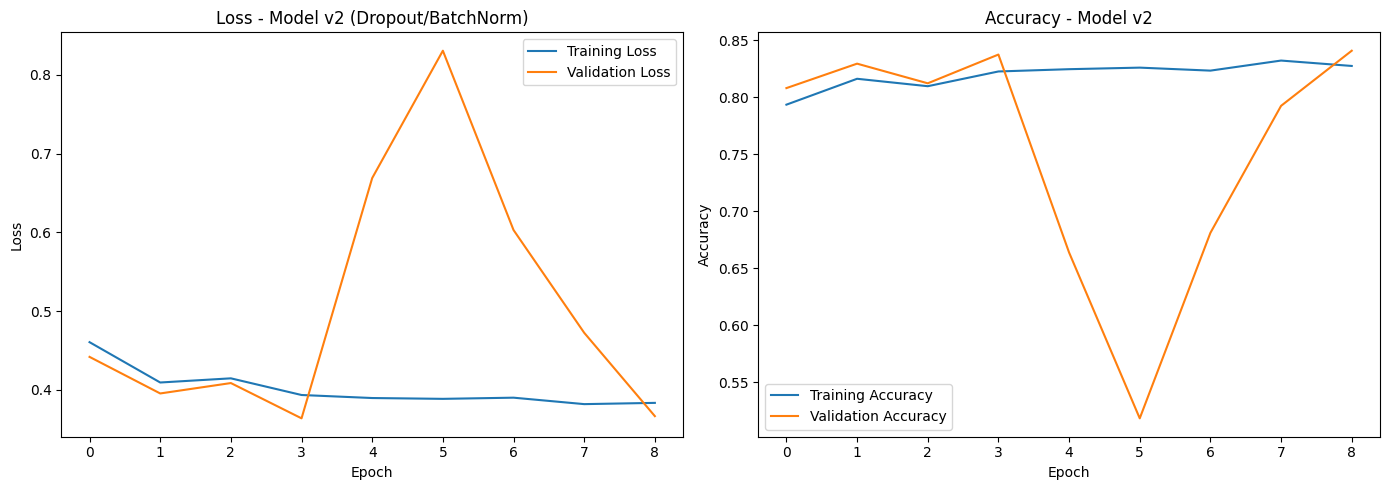

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_v2.history['loss'], label='Training Loss')
axes[0].plot(history_v2.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss - Model v2 (Dropout/BatchNorm)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_v2.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_v2.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy - Model v2')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves_v2.png', dpi=150)
plt.show()

In [ ]:
model_v3 = Sequential([
    Dense(128, activation='relu', input_shape=(12288,)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model_v3.compile(
    optimizer=Adam(learning_rate=0.0001),  # أقل بكثير من قبل
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop_v3 = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

history_v3 = model_v3.fit(
    X_train_flat, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_v3]
)

Epoch 1/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.7815 - loss: 0.4871 - val_accuracy: 0.8043 - val_loss: 0.4123
Epoch 2/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8010 - loss: 0.4535 - val_accuracy: 0.8464 - val_loss: 0.3561
Epoch 3/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7945 - loss: 0.4483 - val_accuracy: 0.7462 - val_loss: 0.5506
Epoch 4/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8030 - loss: 0.4483 - val_accuracy: 0.8194 - val_loss: 0.4009
Epoch 5/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8073 - loss: 0.4337 - val_accuracy: 0.8220 - val_loss: 0.3917
Epoch 6/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8075 - loss: 0.4212 - val_accuracy: 0.7866 - val_loss: 0.5146
Epoch 7/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8066 - loss: 0.4208 - val_accuracy: 0.8418 - val_loss: 0.3583
Epoch 8/50
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8151 - loss: 0.4111 - val_accuracy: 0

In [ ]:
test_loss_v3, test_accuracy_v3 = model_v3.evaluate(X_test_flat, y_test)

print(f'\n=== المقارنة النهائية الشاملة ===')
print(f'Baseline (Logistic Regression):                          {baseline_accuracy:.4f}')
print(f'Neural Network v1 (بدون تحسينات):                         {test_accuracy:.4f}')
print(f'Neural Network v2 (BatchNorm+Dropout 0.3+EarlyStopping):  {test_accuracy_v2:.4f}')
print(f'Neural Network v3 (Dropout 0.4+LR أقل+EarlyStopping):     {test_accuracy_v3:.4f}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8260 - loss: 0.3719

=== المقارنة النهائية الشاملة ===
Baseline (Logistic Regression):                          0.8685
Neural Network v1 (بدون تحسينات):                         0.7070
Neural Network v2 (BatchNorm+Dropout 0.3+EarlyStopping):  0.8220
Neural Network v3 (Dropout 0.4+LR أقل+EarlyStopping):     0.8260


**Diagnosis:** NN v3 (lower learning rate 0.0001, higher dropout 0.4) actually performed the
best of the three neural network versions, reaching 0.8260 — slightly better than v2 (0.8220)
and well above v1 (0.7070), though still below the baseline (0.8685). The loss curve confirms
the model is still unstable — validation loss swings noticeably across epochs even though
training loss stays low and flat. This tells me the model is *not* overfitting in the classic
sense (training loss isn't dropping toward zero while validation rises) — instead validation
performance is just unstable epoch to epoch, and EarlyStopping with restore_best_weights=True
was what let this version land on its best epoch instead of an unlucky one. Note: since both
the learning rate and dropout changed together between v2 and v3, it isn't possible to say
which change (or their combination) is responsible for the small improvement — a cleaner
one-variable-at-a-time experiment would be needed to isolate that in Sprint 2.

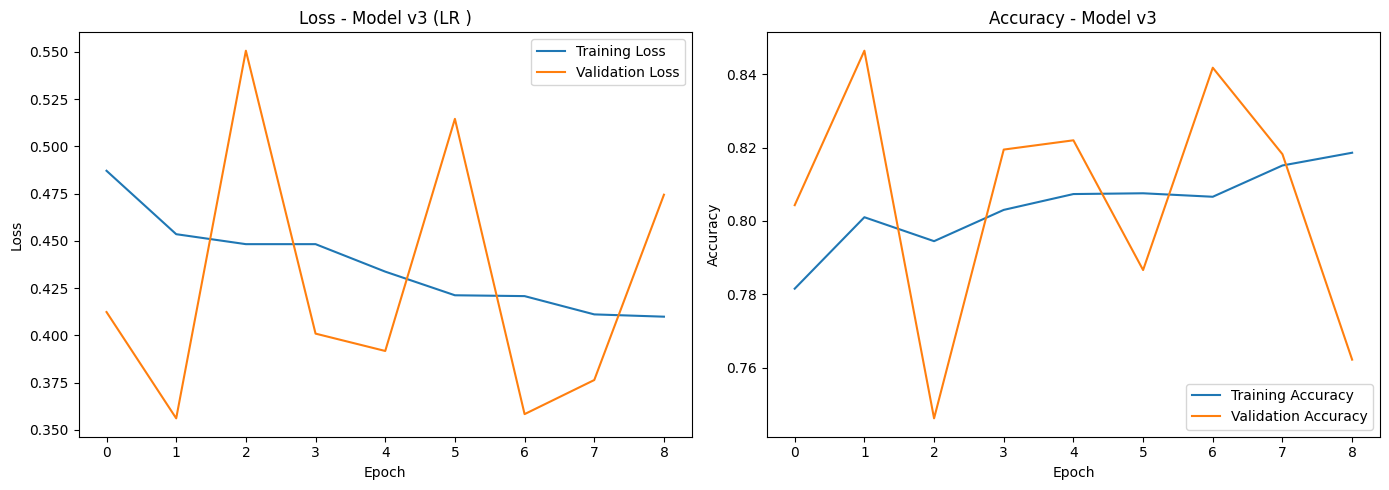

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_v3.history['loss'], label='Training Loss')
axes[0].plot(history_v3.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss - Model v3 (LR )')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_v3.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_v3.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy - Model v3')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves_v3.png', dpi=150)
plt.show()

## Sprint Review

**What was completed this sprint:**
- Dataset selected, explored, and confirmed balanced enough to proceed (6289/5590 train,
  1000/1000 test).
- Baseline model (Logistic Regression) trained and recorded: **0.8685 accuracy**.
- Activation functions understood and visualized (ReLU, Sigmoid, Tanh) plus a manual forward
  pass computed by hand.
- Training loop and backpropagation explained conceptually; learning rate behavior tested
  directly with a mini-experiment.
- Three neural network iterations built, trained, and evaluated:
  - v1 (plain Dense network): 0.7070
  - v2 (BatchNorm + Dropout + EarlyStopping): 0.8220
  - v3 (higher dropout + lower LR + EarlyStopping): 0.8260
- All models compared against the baseline in a single metric table and set of loss/accuracy curves.

**Result vs. the goal:** the sprint goal was to demonstrate that a complex model must be
compared against a simple baseline — and it was, decisively: **none of the three neural
network versions beat the baseline (0.8685).** v3 came closest at 0.8260, still a 4-point gap.
That is a real, honest result, not a failure of the sprint.

## Sprint Retrospective

**What went well:**
- The full pipeline (download → EDA → preprocess → baseline → 3 NN iterations → comparison)
  ran end-to-end without errors.
- Every model's design choice (activation, loss function, optimizer) was justified rather than
  copied blindly from the curriculum example.
- Regularization (BatchNorm + Dropout + EarlyStopping) produced a clear, consistent improvement
  from v1 (0.7070) to v2/v3 (~0.82-0.83), even though the baseline still wasn't beaten.

**What to improve:**
- All three neural network versions showed unstable validation loss curves with large spikes,
  which suggests the batch size, validation split, or lack of data augmentation may be worth
  investigating, rather than just tuning dropout/learning rate in isolation.
- v2 → v3 changed two hyperparameters at once (learning rate and dropout), which breaks the
  one-variable-at-a-time discipline from Week 4/Day 5 — next time each change should be isolated
  so its individual effect can be measured.
- Flattening 224x224 images into a 12,288-length vector throws away all spatial structure,
  which is very likely the real reason a plain Dense network can't beat a much simpler
  Logistic Regression baseline on this data — pixels next to each other stop being "next to
  each other" once flattened.

**One concrete action for Sprint 2:** move from Dense layers on flattened pixels to a
Convolutional Neural Network (Weeks 7-8 topic), since CNNs preserve spatial relationships
between pixels and are specifically designed for image data — this is the most likely path to
actually beating the baseline.